# Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
from src.utils import *
import src.utils as hf 
# from ExampleScript import *

# Analysis

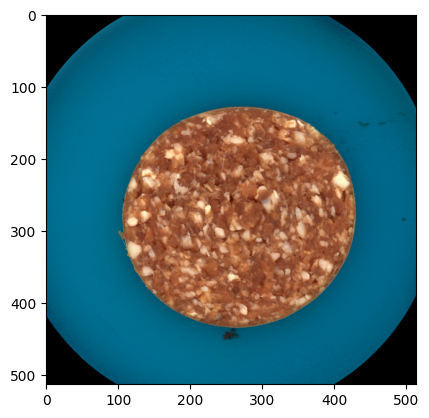

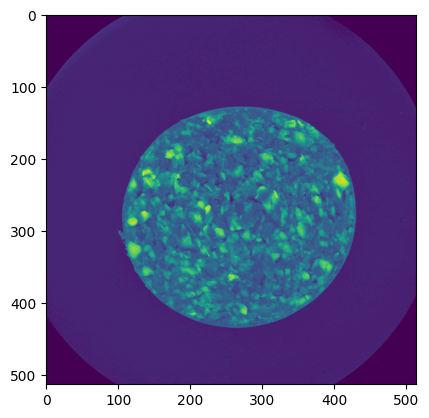

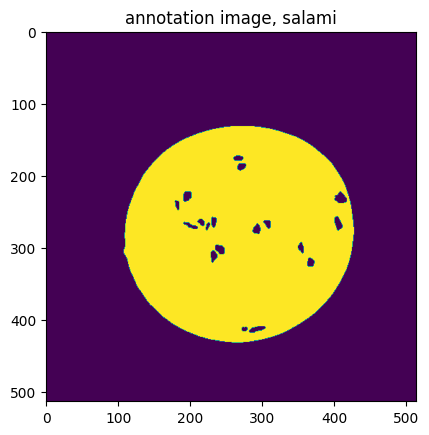

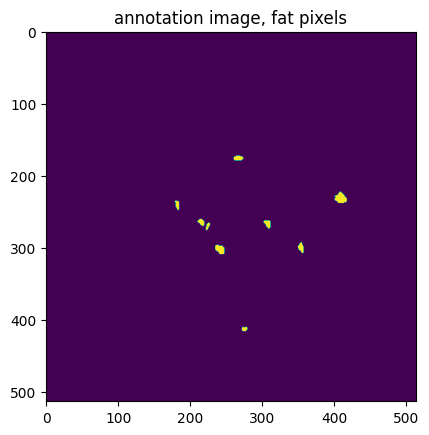

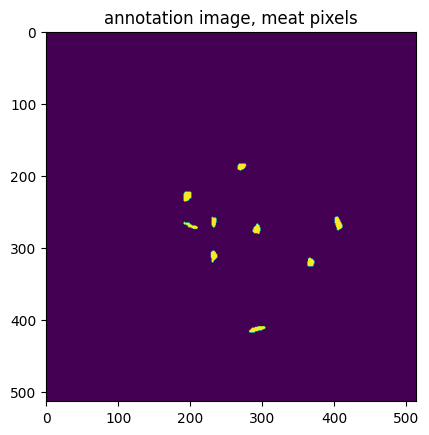

In [17]:
dirIn = "data/"
multiIm, annotationIm = hf.loadMulti('multispectral_day01.mat' , 'annotation_day01.png', dirIn)
imRGB = imread(dirIn + 'color_day01.png')
plt.imshow(imRGB)
plt.show()
plt.imshow(multiIm[:, :, 6])
plt.show()
plt.imshow(annotationIm[:, :, 0])
plt.title("annotation image, salami")
plt.show()
plt.imshow(annotationIm[:, :, 1])
plt.title("annotation image, fat pixels")
plt.show()
plt.imshow(annotationIm[:, :, 2])
plt.title("annotation image, meat pixels")
plt.show()

# Analysis of data

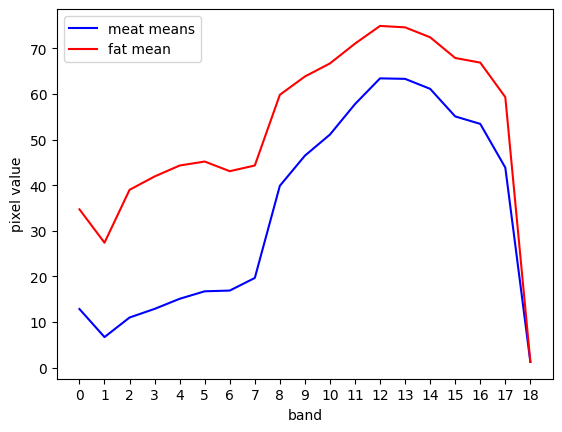

In [18]:
[fatPix, fatR, fatC] = hf.getPix(multiIm, annotationIm[:,:,1])
[meatPix, meatR, meatC] = hf.getPix(multiIm, annotationIm[:,:,2])
meatMean = np.mean(meatPix, 0)
fatMean = np.mean(fatPix, 0)

# Here we plot the mean values for pixels with meat and fat respectively
plt.plot(meatMean,'b', label = "meat means")
plt.plot(fatMean,'r', label = "fat mean")
plt.xticks(range(0, 19), range(0,19))
plt.xlabel("band")
plt.ylabel("pixel value")
plt.legend()
plt.show()

# Threshold value for a single spectral band

In [19]:
day = 1
t = (meatMean + fatMean) / 2
t

array([23.79845037, 17.06151408, 25.00177322, 27.41107262, 29.71776459,
       30.97639933, 29.99817763, 32.00265984, 49.85284289, 55.16145961,
       58.90757941, 64.41891698, 69.17798786, 68.96551428, 66.78297869,
       61.4899176 , 60.16728914, 51.58782782,  1.2867258 ])

In [20]:
correctMeat = meatPix < t
wrongMeat = meatPix > t
correctFat = fatPix > t
wrongFat = fatPix < t
print("meat correctly classified: ", np.sum(correctMeat, 0))
print("meat wrongly classified: ", np.sum(wrongMeat, 0))
print("fat correctly classified: ", np.sum(correctFat, 0))
print("fat wrongly classified: ", np.sum(wrongFat, 0))

meat correctly classified:  [969 969 969 969 969 969 969 969 969 969 969 969 969 968 969 969 969 967
 703]
meat wrongly classified:  [  0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   2
 266]
fat correctly classified:  [738 728 735 741 742 741 743 738 742 738 746 747 737 749 748 740 730 731
 226]
fat wrongly classified:  [ 18  28  21  15  14  15  13  18  14  18  10   9  19   7   8  16  26  25
 530]


In [21]:
errorRate = (np.sum(wrongMeat, 0) + np.sum(wrongFat, 0)) / (np.sum(correctMeat, 0) + np.sum(wrongMeat, 0) + np.sum(correctFat, 0) + np.sum(wrongFat, 0))
print("error rate:", errorRate)
thresholdUse = np.argmin(errorRate)
threshold = t[thresholdUse]
print("best band:", thresholdUse, "with error rate:", errorRate[thresholdUse], "and threshold:", threshold)

error rate: [0.01043478 0.01623188 0.01217391 0.00869565 0.00811594 0.00869565
 0.00753623 0.01043478 0.00811594 0.01043478 0.0057971  0.00521739
 0.01101449 0.00463768 0.00463768 0.00927536 0.01507246 0.01565217
 0.46144928]
best band: 13 with error rate: 0.00463768115942029 and threshold: 68.9655142758858


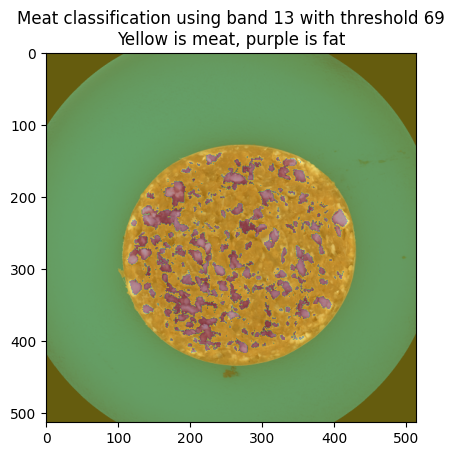

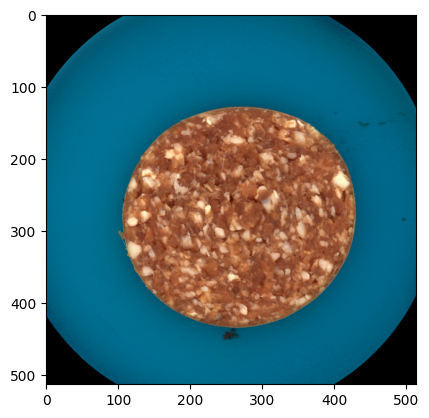

In [22]:
# Classify where the salami is in the image using the best band and threshold and plot it on the color image
meatClass = multiIm[:, :, thresholdUse] < threshold
plt.imshow(imRGB)
plt.imshow(meatClass, alpha = 0.4)
plt.title("Meat classification using band " + str(thresholdUse) + " with threshold " + str(round(threshold)) + "\nYellow is meat, purple is fat")
plt.show()
plt.imshow(imRGB)
plt.show()

# Classification by means of all bands

In [23]:
meatCov = np.cov(meatPix, rowvar=False)
fatCov = np.cov(fatPix, rowvar=False)
meatM = meatPix.shape[0]
fatM = fatPix.shape[0]
pooledCov = (meatM * meatCov + fatM * fatCov) / (meatM + fatM)

def discriminant(x, mean, cov):
    d = x @ np.linalg.inv(cov) @ mean - 0.5 * mean.T @ np.linalg.inv(cov) @ mean
    return d

In [24]:
# calculate error rate using LDA in annotation image
# 1 is fat, 2 is meat
correctMeat = 0
wrongMeat = 0
correctFat = 0
wrongFat = 0
[val, r, c] = hf.getPix(multiIm, annotationIm[:,:,1])
for i in range(val.shape[0]):
    dMeat = discriminant(val[i], meatMean, pooledCov)
    dFat = discriminant(val[i], fatMean, pooledCov)
    if dMeat > dFat:
        wrongFat += 1
    else:
        correctFat += 1

[val, r, c] = hf.getPix(multiIm, annotationIm[:,:,2])
for i in range(val.shape[0]):
    dMeat = discriminant(val[i], meatMean, pooledCov)
    dFat = discriminant(val[i], fatMean, pooledCov)
    if dMeat > dFat:
        correctMeat += 1
    else:
        wrongMeat += 1

errorRateLDA = (wrongMeat + wrongFat) / (correctMeat + wrongMeat + correctFat + wrongFat)
print("error rate LDA:", errorRateLDA)

error rate LDA: 0.005797101449275362


In [25]:
meatDiscriminant = np.array([discriminant(x, meatMean, pooledCov) for x in multiIm.reshape(-1, 19)])
fatDiscriminant = np.array([discriminant(x, fatMean, pooledCov) for x in multiIm.reshape(-1, 19)])
classification = meatDiscriminant > fatDiscriminant
classification = classification.reshape(multiIm.shape[0], multiIm.shape[1])

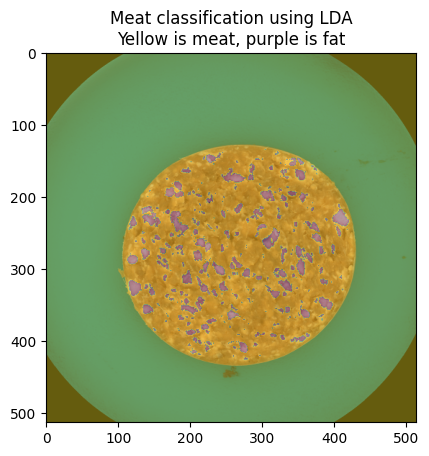

In [26]:
plt.imshow(imRGB)
plt.imshow(classification, alpha = 0.4)
plt.title("Meat classification using LDA\nYellow is meat, purple is fat")
plt.show()

# Calculations for all days

In [27]:
allImgs = [
    hf.loadMulti('multispectral_day01.mat' , 'annotation_day01.png', dirIn),
    hf.loadMulti('multispectral_day06.mat' , 'annotation_day06.png', dirIn),
    hf.loadMulti('multispectral_day13.mat' , 'annotation_day13.png', dirIn),
    hf.loadMulti('multispectral_day20.mat' , 'annotation_day20.png', dirIn),
    hf.loadMulti('multispectral_day28.mat' , 'annotation_day28.png', dirIn),
]
days = ["01", "06", "13", "20", "28"]

### Model 1

In [28]:
# error rates for remaining days using thresholding
errorRates = []
for mIm, aIm in allImgs:
    [fatPix, fatR, fatC] = hf.getPix(mIm, aIm[:,:,1])
    [meatPix, meatR, meatC] = hf.getPix(mIm, aIm[:,:,2])
    correctMeat = meatPix < threshold
    wrongMeat = meatPix > threshold
    correctFat = fatPix > threshold
    wrongFat = fatPix < threshold
    errorRate = (np.sum(wrongMeat, 0) + np.sum(wrongFat, 0)) / (np.sum(correctMeat, 0) + np.sum(wrongMeat, 0) + np.sum(correctFat, 0) + np.sum(wrongFat, 0))
    errorRates.append(errorRate[thresholdUse])

In [29]:
for i, e in enumerate(errorRates):
    print("error rate thresholding for day " + days[i] + ": " + str(e))

error rate thresholding for day 01: 0.00463768115942029
error rate thresholding for day 06: 0.12319538017324351
error rate thresholding for day 13: 0.12372372372372373
error rate thresholding for day 20: 0.24176470588235294
error rate thresholding for day 28: 0.18243243243243243


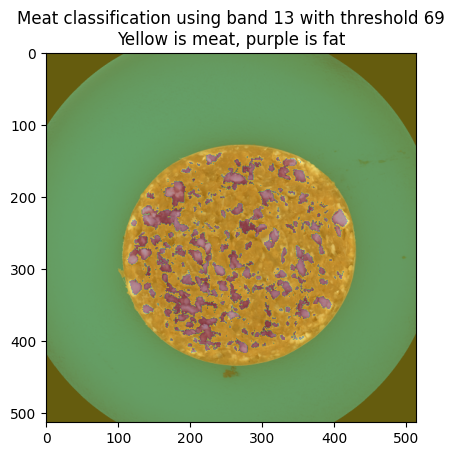

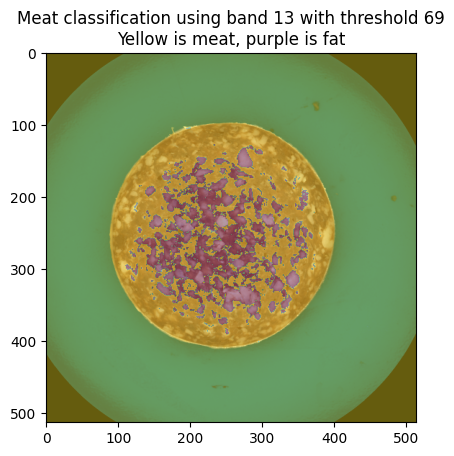

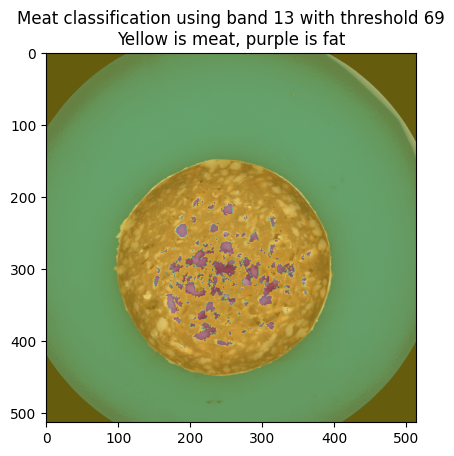

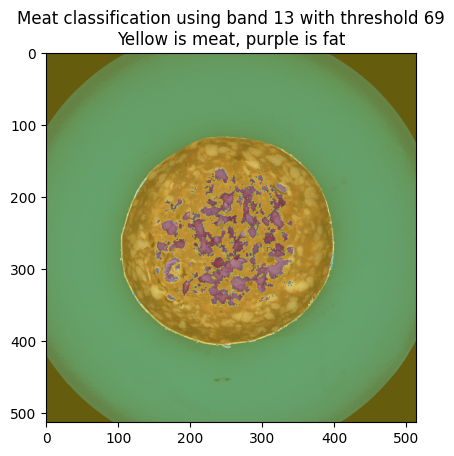

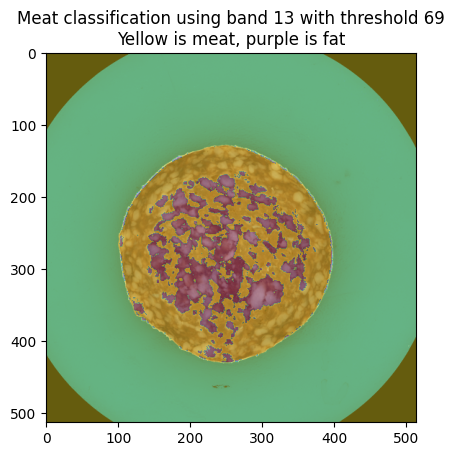

In [30]:
# classify the rest of the images using thresholding and plot the results
for i, (mIm, aIm) in enumerate(allImgs):
    imRGB = imread(dirIn + 'color_day' + days[i] + '.png')
    meatClass = mIm[:, :, thresholdUse] < threshold
    plt.imshow(imRGB)
    plt.imshow(meatClass, alpha = 0.4)
    plt.title("Meat classification using band " + str(thresholdUse) + " with threshold " + str(round(threshold)) + "\nYellow is meat, purple is fat")
    plt.show()

### Model 2

In [31]:
# error rates for remaining days
errorRatesLDA = []
for mIm, aIm in allImgs:
    [val, r, c] = hf.getPix(mIm, aIm[:,:,1])
    correctMeat = 0
    wrongMeat = 0
    correctFat = 0
    wrongFat = 0
    for i in range(val.shape[0]):
        dMeat = discriminant(val[i], meatMean, pooledCov)
        dFat = discriminant(val[i], fatMean, pooledCov)
        if dMeat > dFat:
            wrongMeat += 1
        else:
            correctFat += 1

    [val, r, c] = hf.getPix(mIm, aIm[:,:,2])
    for i in range(val.shape[0]):
        dMeat = discriminant(val[i], meatMean, pooledCov)
        dFat = discriminant(val[i], fatMean, pooledCov)
        if dMeat > dFat:
            correctMeat += 1
        else:
            wrongFat += 1

    errorRateLDA = (wrongMeat + wrongFat) / (correctMeat + wrongMeat + correctFat + wrongFat)
    errorRatesLDA.append(errorRateLDA)

In [32]:
for i, e in enumerate(errorRatesLDA):
    print("error rate LDA for day " + days[i] + ": " + str(e))

error rate LDA for day 01: 0.005797101449275362
error rate LDA for day 06: 0.021174205967276226
error rate LDA for day 13: 0.08588588588588589
error rate LDA for day 20: 0.1388235294117647
error rate LDA for day 28: 0.059845559845559844


In [33]:
#Classify the rest of the images using LDA and save the results in a list for further use (e.g. calculating error rate, plotting etc.)
classifications = []
for mIm, aIm in allImgs:
    meatDiscriminant = np.array([discriminant(x, meatMean, pooledCov) for x in mIm.reshape(-1, 19)])
    fatDiscriminant = np.array([discriminant(x, fatMean, pooledCov) for x in mIm.reshape(-1, 19)])
    classification = meatDiscriminant > fatDiscriminant
    classification = classification.reshape(mIm.shape[0], mIm.shape[1])
    classifications.append(classification)

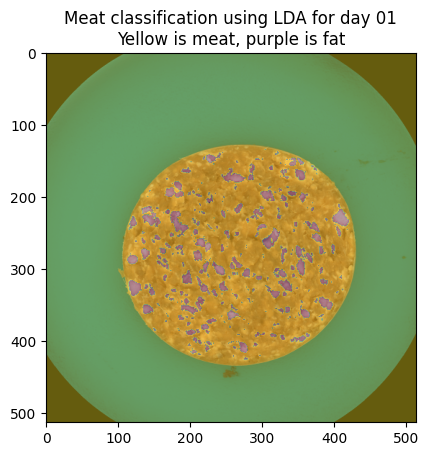

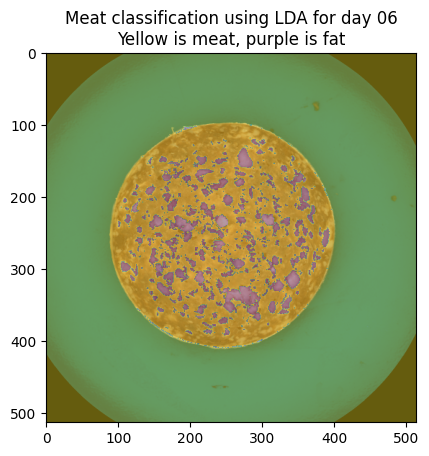

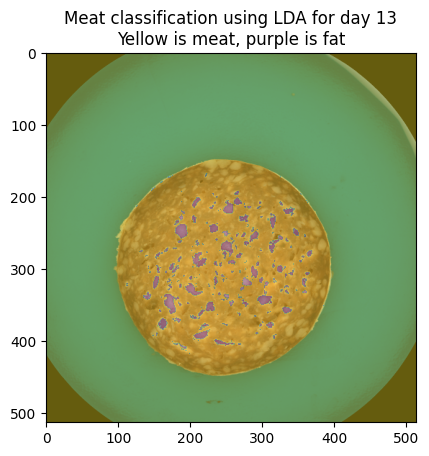

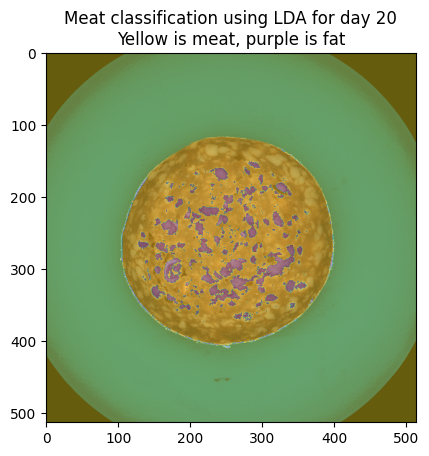

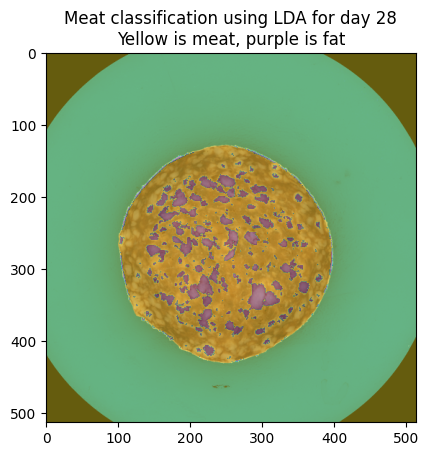

In [34]:
# Show all classifications next to the color images
for i, (mIm, aIm) in enumerate(allImgs):
    imRGB = imread(dirIn + 'color_day' + days[i] + '.png')
    plt.imshow(imRGB)
    plt.imshow(classifications[i], alpha = 0.4)
    plt.title("Meat classification using LDA for day " + days[i] + "\nYellow is meat, purple is fat")
    plt.show()

# Training on each day and error calculated on all the other days

In [35]:
def LDA(mMean, fMean, cov):
    # error rates for remaining days
    errorRatesLDA = []
    for mIm, aIm in allImgs:
        [val, r, c] = hf.getPix(mIm, aIm[:,:,1])
        correctMeat = 0
        wrongMeat = 0
        correctFat = 0
        wrongFat = 0
        for i in range(val.shape[0]):
            dMeat = discriminant(val[i], mMean, cov)
            dFat = discriminant(val[i], fMean, cov)
            if dMeat > dFat:
                wrongMeat += 1
            else:
                correctFat += 1

        [val, r, c] = hf.getPix(mIm, aIm[:,:,2])
        for i in range(val.shape[0]):
            dMeat = discriminant(val[i], mMean, cov)
            dFat = discriminant(val[i], fMean, cov)
            if dMeat > dFat:
                correctMeat += 1
            else:
                wrongFat += 1

        errorRateLDA = (wrongMeat + wrongFat) / (correctMeat + wrongMeat + correctFat + wrongFat)
        errorRatesLDA.append(errorRateLDA)

        # for i, e in enumerate(errorRatesLDA):
        #     print("error rate LDA for day " + days[i] + ": " + str(e))

        # #Classify the rest of the images using LDA and save the results in a list for further use (e.g. calculating error rate, plotting etc.)
        # classifications = []
        # for mIm, aIm in allImgs:
        #     meatDiscriminant = np.array([discriminant(x, meatMean, cov) for x in mIm.reshape(-1, 19)])
        #     fatDiscriminant = np.array([discriminant(x, fatMean, cov) for x in mIm.reshape(-1, 19)])
        #     classification = meatDiscriminant > fatDiscriminant
        #     classification = classification.reshape(mIm.shape[0], mIm.shape[1])
        #     classifications.append(classification)
        # # Show all classifications next to the color images
        # for i, (mIm, aIm) in enumerate(allImgs):
        #     imRGB = imread(dirIn + 'color_day' + days[i] + '.png')
        #     plt.imshow(imRGB)
        #     plt.imshow(classifications[i], alpha = 0.4)
        #     plt.title("Meat classification using LDA for day " + days[i] + "\nYellow is meat, purple is fat")
        #     plt.show()

    return errorRatesLDA


In [36]:
# get error rates for LDA using the means and covariances calculated from all days
errorRatesLDA = []
for mIm, aIm in allImgs:
    [fPix, fR, fC] = hf.getPix(mIm, aIm[:,:,1])
    [mPix, mR, mC] = hf.getPix(mIm, aIm[:,:,2])
    mMean = np.mean(mPix, 0)
    fMean = np.mean(fPix, 0)
    mCov = np.cov(mPix, rowvar=False)
    fCov = np.cov(fPix, rowvar=False)
    meatM = mPix.shape[0]
    fatM = fPix.shape[0]
    pooledCov = (meatM * mCov + fatM * fCov) / (meatM + fatM)
    errorRatesLDA.append(LDA(mMean, fMean, pooledCov))

In [37]:
for i in range(5):
    for j in range(5):
        print("error rate using day:", days[i], "on day", days[j], "is", errorRatesLDA[i][j])
    print()

error rate using day: 01 on day 01 is 0.005797101449275362
error rate using day: 01 on day 06 is 0.021174205967276226
error rate using day: 01 on day 13 is 0.08588588588588589
error rate using day: 01 on day 20 is 0.1388235294117647
error rate using day: 01 on day 28 is 0.059845559845559844

error rate using day: 06 on day 01 is 0.02318840579710145
error rate using day: 06 on day 06 is 0.0019249278152069298
error rate using day: 06 on day 13 is 0.015615615615615615
error rate using day: 06 on day 20 is 0.042352941176470586
error rate using day: 06 on day 28 is 0.04247104247104247

error rate using day: 13 on day 01 is 0.011014492753623189
error rate using day: 13 on day 06 is 0.0014436958614051972
error rate using day: 13 on day 13 is 0.0006006006006006006
error rate using day: 13 on day 20 is 0.02
error rate using day: 13 on day 28 is 0.014961389961389961

error rate using day: 20 on day 01 is 0.011014492753623189
error rate using day: 20 on day 06 is 0.011068334937439845
error rate u

In [38]:
# tabular form
for i in range(5):
    for j in range(5):
        if i == j:
            print("X", end="\t")
        else:
            print(round(errorRatesLDA[i][j], 5), end="\t")
    print()

X	0.02117	0.08589	0.13882	0.05985	
0.02319	X	0.01562	0.04235	0.04247	
0.01101	0.00144	X	0.02	0.01496	
0.01101	0.01107	0.0036	X	0.04923	
0.00696	0.0231	0.01021	0.00118	X	


# Prior knowledge

In [39]:
pFat = 0.3
pMeat = 0.7

In [40]:
def discriminantPrior(x, mean, cov, prior):
    d = x @ np.linalg.inv(cov) @ mean - 0.5 * mean.T @ np.linalg.inv(cov) @ mean + np.log(prior)
    return d

In [41]:
def LDAPrior(mMean, fMean, cov, priorMeat, priorFat):
    # error rates for remaining days
    errorRatesLDA = []
    for mIm, aIm in allImgs:
        [val, r, c] = hf.getPix(mIm, aIm[:,:,1])
        correctMeat = 0
        wrongMeat = 0
        correctFat = 0
        wrongFat = 0
        for i in range(val.shape[0]):
            dMeat = discriminantPrior(val[i], mMean, cov, priorMeat)
            dFat = discriminantPrior(val[i], fMean, cov, priorFat)
            if dMeat > dFat:
                wrongMeat += 1
            else:
                correctFat += 1

        [val, r, c] = hf.getPix(mIm, aIm[:,:,2])
        for i in range(val.shape[0]):
            dMeat = discriminantPrior(val[i], mMean, cov, priorMeat)
            dFat = discriminantPrior(val[i], fMean, cov, priorFat)
            if dMeat > dFat:
                correctMeat += 1
            else:
                wrongFat += 1

        errorRateLDA = (wrongMeat + wrongFat) / (correctMeat + wrongMeat + correctFat + wrongFat)
        errorRatesLDA.append(errorRateLDA)

    return errorRatesLDA


In [42]:
errorRatesLDAPrior = []
for mIm, aIm in allImgs:
    [fPix, fR, fC] = hf.getPix(mIm, aIm[:,:,1])
    [mPix, mR, mC] = hf.getPix(mIm, aIm[:,:,2])
    mMean = np.mean(mPix, 0)
    fMean = np.mean(fPix, 0)
    mCov = np.cov(mPix, rowvar=False)
    fCov = np.cov(fPix, rowvar=False)
    meatM = mPix.shape[0]
    fatM = fPix.shape[0]
    pooledCov = (meatM * mCov + fatM * fCov) / (meatM + fatM)
    errorRatesLDAPrior.append(LDAPrior(mMean, fMean, pooledCov, pMeat, pFat))

In [43]:
for i in range(5):
    for j in range(5):
        print("error rate using day:", days[i], "on day", days[j], "is", errorRatesLDAPrior[i][j])
    print()

error rate using day: 01 on day 01 is 0.005797101449275362
error rate using day: 01 on day 06 is 0.02165543792107796
error rate using day: 01 on day 13 is 0.08768768768768768
error rate using day: 01 on day 20 is 0.14
error rate using day: 01 on day 28 is 0.06322393822393822

error rate using day: 06 on day 01 is 0.02434782608695652
error rate using day: 06 on day 06 is 0.002406159769008662
error rate using day: 06 on day 13 is 0.016816816816816817
error rate using day: 06 on day 20 is 0.04588235294117647
error rate using day: 06 on day 28 is 0.045366795366795366

error rate using day: 13 on day 01 is 0.01217391304347826
error rate using day: 13 on day 06 is 0.0019249278152069298
error rate using day: 13 on day 13 is 0.0012012012012012011
error rate using day: 13 on day 20 is 0.027058823529411764
error rate using day: 13 on day 28 is 0.01833976833976834

error rate using day: 20 on day 01 is 0.011014492753623189
error rate using day: 20 on day 06 is 0.008180943214629451
error rate usin

In [44]:
# tabular form
for i in range(5):
    for j in range(5):
        if i == j:
            print("X", end="\t")
        else:
            print(round(errorRatesLDAPrior[i][j], 5), end="\t")
    print()

X	0.02166	0.08769	0.14	0.06322	
0.02435	X	0.01682	0.04588	0.04537	
0.01217	0.00192	X	0.02706	0.01834	
0.01101	0.00818	0.0036	X	0.05164	
0.0058	0.01781	0.00781	0.00294	X	


In [45]:
# for comparison, this is the old table without priors
for i in range(5):
    for j in range(5):
        if i == j:
            print("X", end="\t")
        else:
            print(round(errorRatesLDA[i][j], 5), end="\t")
    print()

X	0.02117	0.08589	0.13882	0.05985	
0.02319	X	0.01562	0.04235	0.04247	
0.01101	0.00144	X	0.02	0.01496	
0.01101	0.01107	0.0036	X	0.04923	
0.00696	0.0231	0.01021	0.00118	X	
